## Transfer Learning and Fine-Tuning for Dog Classification

This notebook implements transfer learning and fine-tuning using pretrained ImageNet models to classify dog images into three classes:

- diego_dog
- lalo_dog
- standford_dogs_subset (any other dog)

In [1]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import copy
import seaborn as sns
import pandas as pd
import time

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from torch.optim import Adam
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
data_dir = Path("./images")

class_names = ["diego_dog", "lalo_dog", "standford_dogs_subset"]
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

In [5]:
image_extensions = {".jpg", ".jpeg", ".png"}

samples = []

for class_name in class_names:
    class_dir = data_dir / class_name
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            samples.append((str(img_path), class_to_idx[class_name]))

len(samples)

60

In [6]:
paths = [path for path, label in samples]
labels = [label for path, label in samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print(len(train_paths), len(val_paths), len(test_paths))

48 6 6


In [7]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [8]:
class DogDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
train_data = DogDataset(train_paths, train_labels, train_transform)
val_data = DogDataset(val_paths, val_labels, eval_transform)
test_data = DogDataset(test_paths, test_labels, eval_transform)

batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Funciones de entrenamiento

In [10]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for _ in tqdm(range(epochs)):
        model.train()
        train_loss = 0.0
        train_correct = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            pred = output.argmax(dim=1)
            train_correct += (pred == y).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                output = model(x)
                loss = criterion(output, y)

                val_loss += loss.item() * x.size(0)
                pred = output.argmax(dim=1)
                val_correct += (pred == y).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        res['train_loss'].append(train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(val_loss)
        res['val_acc'].append(val_acc)

    return res

## Graficar curvas


In [11]:
def plot_losses(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_loss'], label='train')
    plt.plot(res['val_loss'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_accuracies(res, title):
    plt.figure(figsize=(6, 4))
    plt.plot(res['train_acc'], label='train')
    plt.plot(res['val_acc'], label='validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## Model 1: ResNet18 Transfer Learning

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\eduar/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:28<00:00, 1.65MB/s]
100%|██████████| 10/10 [01:54<00:00, 11.47s/it]


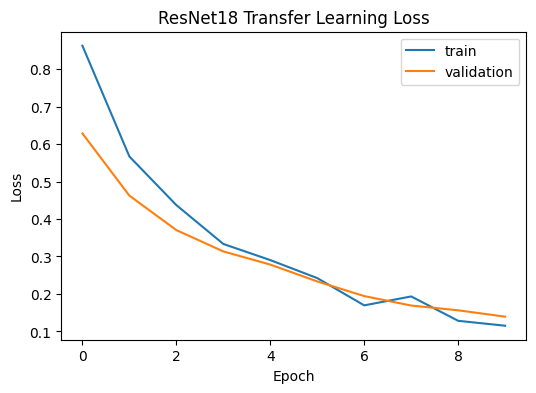

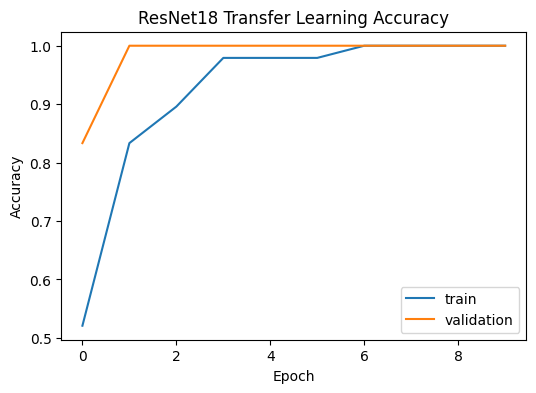

In [12]:
# Entrenar modelo resnet con transfer learning

weights = ResNet18_Weights.DEFAULT
model_resnet_tl = resnet18(weights=weights)

for param in model_resnet_tl.parameters():
    param.requires_grad = False

num_features = model_resnet_tl.fc.in_features
model_resnet_tl.fc = nn.Linear(num_features, num_classes)
model_resnet_tl = model_resnet_tl.to(device)

epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_resnet_tl.fc.parameters(), lr=0.001)

resnet_tl_res = train(
    model_resnet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_tl_res, 'ResNet18 Transfer Learning Loss')
plot_accuracies(resnet_tl_res, 'ResNet18 Transfer Learning Accuracy')

## Model 1: ResNet18 Fine-Tuning 

100%|██████████| 10/10 [02:07<00:00, 12.74s/it]


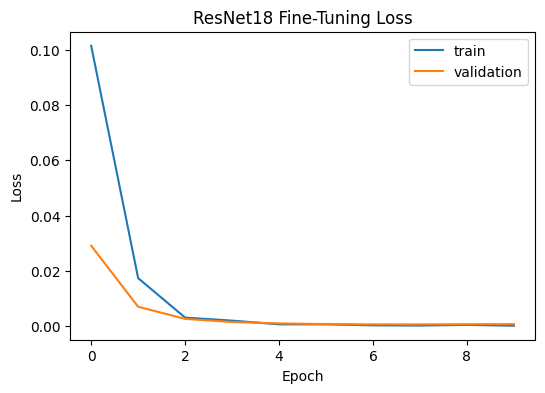

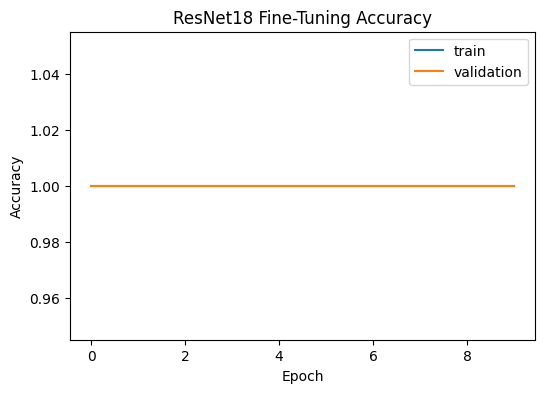

In [13]:
# Entrenar modelo resnet con fine tuning

model_resnet_ft = copy.deepcopy(model_resnet_tl)

for param in model_resnet_ft.parameters():
    param.requires_grad = False

for param in model_resnet_ft.layer4.parameters():
    param.requires_grad = True

for param in model_resnet_ft.fc.parameters():
    param.requires_grad = True

optimizer = Adam(
    filter(lambda p: p.requires_grad, model_resnet_ft.parameters()),
    lr=1e-4
)

resnet_ft_res = train(
    model_resnet_ft,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(resnet_ft_res, 'ResNet18 Fine-Tuning Loss')
plot_accuracies(resnet_ft_res, 'ResNet18 Fine-Tuning Accuracy')

## Model 2: MobileNet Transfer Learning

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\eduar/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:11<00:00, 1.21MB/s]
100%|██████████| 10/10 [01:54<00:00, 11.48s/it]


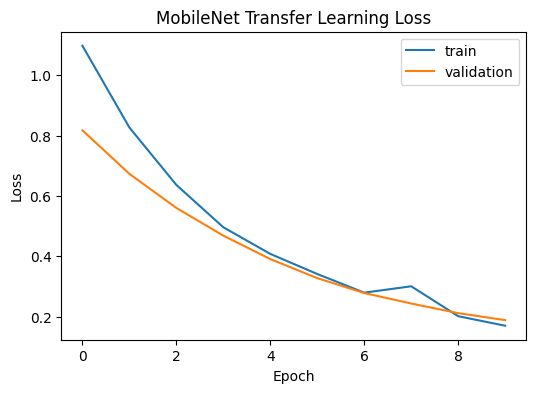

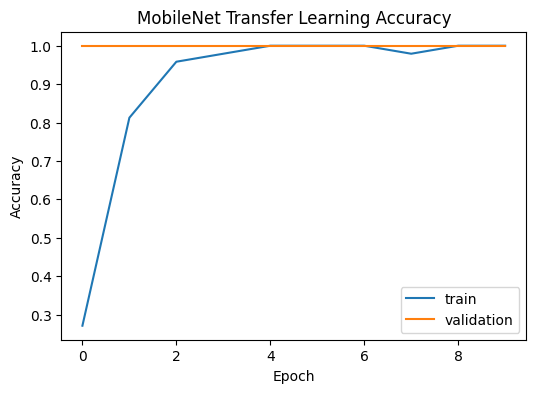

In [14]:
# Entrenar modelo mobilenet con transfer learning

weights = MobileNet_V2_Weights.DEFAULT
model_mobilenet_tl = mobilenet_v2(weights=weights)

for param in model_mobilenet_tl.parameters():
    param.requires_grad = False

num_features = model_mobilenet_tl.classifier[1].in_features
model_mobilenet_tl.classifier[1] = nn.Linear(num_features, num_classes)

model_mobilenet_tl = model_mobilenet_tl.to(device)

optimizer = Adam(model_mobilenet_tl.classifier.parameters(), lr=0.001)

mobilenet_tl_res = train(
    model_mobilenet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(mobilenet_tl_res, 'MobileNet Transfer Learning Loss')
plot_accuracies(mobilenet_tl_res, 'MobileNet Transfer Learning Accuracy')

## Model 2: MobileNet Fine-Tuning

100%|██████████| 10/10 [02:10<00:00, 13.06s/it]


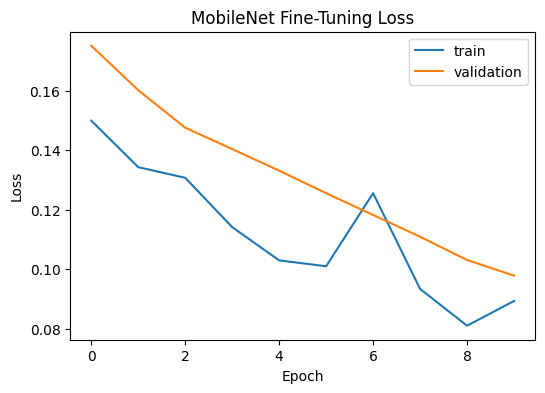

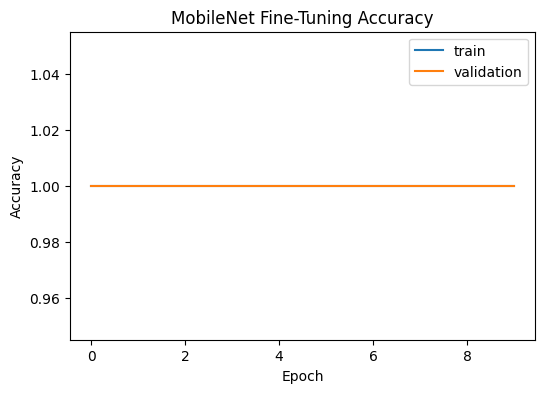

In [15]:
# Entrenar modelo mobilenet con fine tuning

model_mobilenet_ft = copy.deepcopy(model_mobilenet_tl)

for param in model_mobilenet_ft.parameters():
    param.requires_grad = False


for param in model_mobilenet_ft.features[-1].parameters():
    param.requires_grad = True

for param in model_mobilenet_ft.classifier.parameters():
    param.requires_grad = True

optimizer = Adam(
    filter(lambda p: p.requires_grad, model_mobilenet_ft.parameters()),
    lr=1e-4
)

mobilenet_ft_res = train(
    model_mobilenet_ft,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
)

plot_losses(mobilenet_ft_res, 'MobileNet Fine-Tuning Loss')
plot_accuracies(mobilenet_ft_res, 'MobileNet Fine-Tuning Accuracy')

Nota: En los modelos se observa que el accuracy es constante en todas las épocas (con un valor de 1) en los modelos de Fine-Tuning. El equipo considera que esto pasa debido a que estos modelos usan como base los modelos con Transfer Learning, por lo que ya tienen conocimiento y entrenamiento del nuevo conjunto de datos personalizado.

## Evaluacion y Comparacion

In [16]:
# Comparación de los modelos en conjunto de validación y elección del mejor modelo

def evaluate_model_validation(model, dataloader, criterion):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    start_time = time.time()
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += x.size(0)
    
    end_time = time.time()
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    inference_time = end_time - start_time
    
    return avg_loss, accuracy, inference_time


results_table = []

models_dict = {
    "ResNet18 TL": model_resnet_tl,
    "ResNet18 FT": model_resnet_ft,
    "MobileNet TL": model_mobilenet_tl,
    "MobileNet FT": model_mobilenet_ft,
}

for name, model in models_dict.items():
    val_loss, val_acc, inf_time = evaluate_model_validation(model, val_loader, criterion)
    
    results_table.append({
        "Model": name,
        "Val Loss": val_loss,
        "Val Accuracy": val_acc,
        "Inference Time (s)": inf_time
    })

df_results = pd.DataFrame(results_table)

df_results

,Model,Val Loss,Val Accuracy,Inference Time (s)
0,ResNet18 TL,0.139356,1.0,1.708716
1,ResNet18 FT,0.000712,1.0,1.452667
2,MobileNet TL,0.188475,1.0,1.569176
3,MobileNet FT,0.097863,1.0,1.269538


Se eligió el modelo ResNet18 con Fine-Tuning ya que este presenta la pérdida de validación más pequeña. A pesar de no ser el más rápido en inferencia, la diferencia en pérdida es más significativa que la de tiempo de inferencia.

In [17]:
best_model = model_resnet_ft

                       precision    recall  f1-score   support

            diego_dog       1.00      1.00      1.00         3
             lalo_dog       1.00      1.00      1.00         3
standford_dogs_subset       0.00      0.00      0.00         0

             accuracy                           1.00         6
            macro avg       0.67      0.67      0.67         6
         weighted avg       1.00      1.00      1.00         6

Classes in y_true: [0 1]
Classes in y_pred: [0 1]


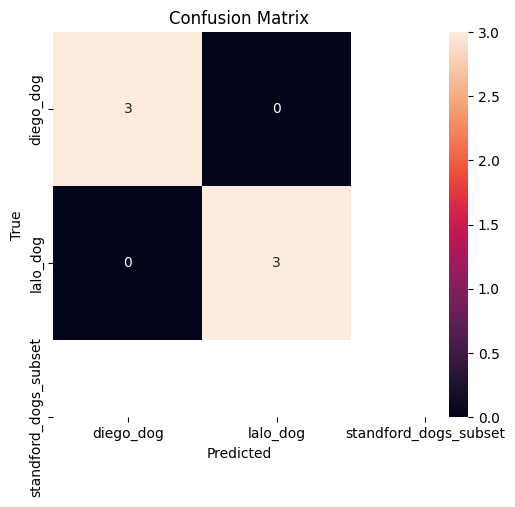

In [23]:
# Reporte del mejor modelo en conjunto de prueba 

def evaluate(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            output = model(x)

            preds = output.argmax(dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = evaluate(best_model, test_loader)

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

print("Classes in y_true:", np.unique(y_true))
print("Classes in y_pred:", np.unique(y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Nota: En el conjunto de prueba, no hay ejemplos de la clase standford_dogs_subset, razón por la cual estos valores salen en cero en el reporte de métricas y que no se muestren valores para esta clase en la matriz de confusión.

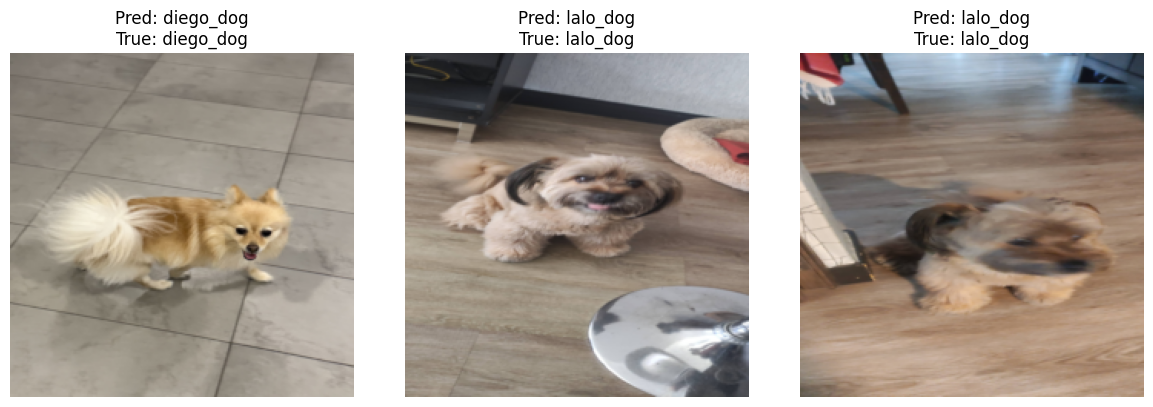

In [22]:
# Prueba del mejor modelo con imagenes aleatorias de prueba

def show_random_predictions(model, dataset, class_names, num_samples=3):
    model.eval()
    
    indices = random.sample(range(len(dataset)), num_samples)
    
    plt.figure(figsize=(12, 4))
    
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        
        # guardar copia para mostrar
        img_to_show = image.clone()
        
        # desnormalizar
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_to_show = img_to_show * std + mean
        img_to_show = torch.clamp(img_to_show, 0, 1)
        
        # predicción
        with torch.no_grad():
            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img_to_show.permute(1, 2, 0).cpu().numpy())
        
        true_label = class_names[label]
        pred_label = class_names[pred]
        
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_predictions(best_model, test_data, class_names)

## Reflexion Personal Diego:

## Reflexion Personal Eduardo:

Realizar esta tarea me permitió aprender a aprovechar modelos preentrenados para agilizar de gran manera la creación de un modelo para cierta tarea. El transfer learning se aprovecha todo el mode ya entrenado previamente y solo se reemplaza y entrena la capa de salida. Esto hace que al entrenar, sea mucho más rápido que entrenar todo un modelo completo desde cero. Por otro lado, el Fine-Tuning consiste en tomar como base un modelo con Transfer Learning y aplicar el mismo entrenamiento que se aplicó con este método, solo que esta vez se activan algunas de las capas finales del modelo preentenado, entrenando así estas últimas capas y la nueva capa final. Al comparar los modelos generados en esta actividad, nos dimos cuenta de que aquellos que usaron Fine-Tuning tuvieron mejores resultados que los que tienen solo Transfer Learning. A pesar de esto, ambos tipos de modelos tuvieron resultados bastante aceptables. Creo que esta diferencia de desempeño entre modelos con Transfer learning y Fine-Tuning es un poco injusta ya que los modelos con Fine-Tuning usa como base los modelos Transfer Learning, por lo que ya tienen el aprednizaje de estos. Debido a esto es injusto decir que uno es mejor que otro. En mi caso prefiero verlo como que uno es una mejora del otro. Sin embargo, cabe aclarar que considero que aplicar Fine Tuning puede causar overfitting, por lo que no siempre será mejor que Transfer Learning. En el caso de esta actividad, no fue posible apreciar esto tan claro ya que el dataset personalizado fue demasiado pequeño. De hecho esto también causó algunos problemas en la particion de los datos, pues nos pasó que una clase no estaba presente en el conjunto de prueba. A pesar de esto, la actividad formó las bases para aplicar estas técnicas, las cuales pueden hacer que el desarrollo de un modelo sea mucho más rápido y sin necesidad de reinventar la rueda.